## BULIDING THE MODELS WTH DIFFERENT TECHNIQUES

In [46]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score
import ipywidgets as widgets
from ipywidgets import interact


In [2]:
poland_df = pd.read_csv("data/poland_df1.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
0,0.159290,0.46240,0.07773,1.1683,-44.853,0.467020,0.189480,0.82895,1.1223,0.38330,...,0.108990,0.41557,0.89101,0.001422,7.7928,4.9914,119.810,3.0465,3.0560,0
1,-0.127430,0.46243,0.26917,1.7517,7.597,0.000925,-0.127430,1.16250,1.2944,0.53757,...,-0.089372,-0.23704,1.06250,0.150410,5.4327,3.4629,100.970,3.6150,3.4725,0
2,0.070488,0.23570,0.52781,3.2393,125.680,0.163670,0.086895,2.87180,1.0574,0.67689,...,0.054286,0.10413,0.94571,0.000000,7.1070,3.3808,76.076,4.7978,4.7818,0
3,0.136760,0.40538,0.31543,1.8705,19.115,0.504970,0.136760,1.45390,1.1144,0.58938,...,0.102630,0.23203,0.89737,0.073024,6.1384,4.2241,88.299,4.1337,4.6484,0
4,-0.110080,0.69793,0.18878,1.2713,-15.344,0.000000,-0.110080,0.43282,1.7350,0.30207,...,0.439880,-0.36440,0.57153,0.000000,18.8010,2.7925,146.390,2.4934,15.0360,0


## Addressing The Class Balance Issue

In [3]:
#splitting the Data
X = poland_df.drop(columns="bankrupt")
y = poland_df["bankrupt"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**The Oversampling Technique**

In [4]:
# Applying Random Oversampler on training data only
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

#Checking for the escence of OverSampling
y_train_over.value_counts(normalize=True)

bankrupt
0    0.5
1    0.5
Name: proportion, dtype: float64

# The Decison Tree Model

In [5]:
#With out oversampling
model_reg = make_pipeline(
    SimpleImputer(strategy="median"), 
    DecisionTreeClassifier(random_state=42)) 
# with Oversampling
model_over = make_pipeline(
    SimpleImputer(strategy="median"), 
    DecisionTreeClassifier(random_state=42)) 

model_reg.fit(X_train,y_train) 
model_over.fit(X_train_over,y_train_over)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness desp

# Testing Accuracy

In [6]:
#computing the test_accuary and train_accuracy
for m in [model_reg,model_over]:
    acc_train = m.score(X_train, y_train)
    acc_test = m.score(X_test,y_test)
    print("acc_train:" ,acc_train)
    print("acc_test:", acc_test)

acc_train: 1.0
acc_test: 0.9536919709710863
acc_train: 1.0
acc_test: 0.9481626540721115


# The confusion Matrix

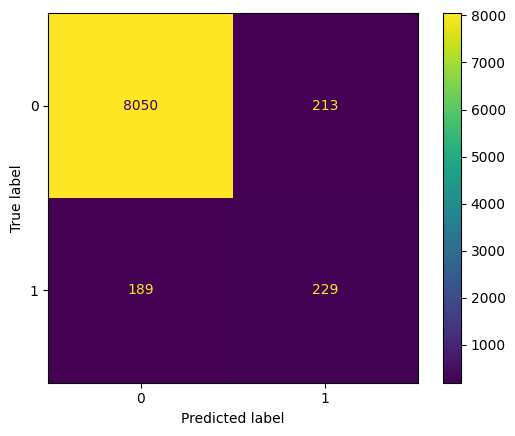

In [7]:
ConfusionMatrixDisplay.from_estimator(model_reg,X_test,y_test);

# Feature Importance

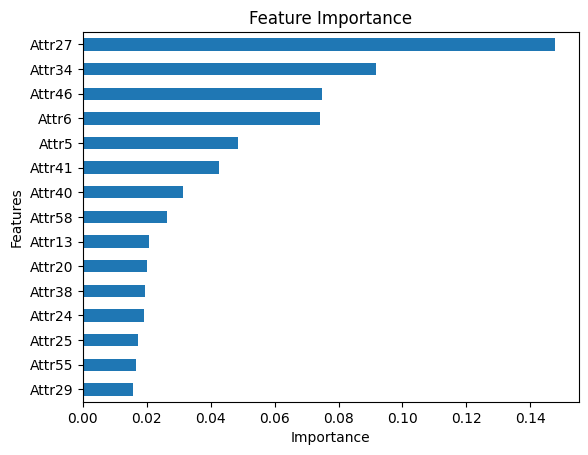

In [8]:
importances = model_over.named_steps["decisiontreeclassifier"].feature_importances_
features = X_train_over.columns
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

# Classification Report For Decision Tree Classifier

classification_report= classification_report(y_test,model_boost.predict(X_test))
print(classification_report)

## Ensemble Methods 
**Ensemble Methods work by building multiple models on random subsets of the same data,compare predictionsand make final predictions**
***The Random Froest Classifier***

In [9]:
# A classifier that uses random forest
classifier = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(classifier,X_train_over,y_train_over,cv=5,n_jobs=-1)

**Hyperparameter Tuning**

In [10]:
params = {
    "randomforestclassifier__n_estimators": range(25,100,25),
    "randomforestclassifier__max_depth":range(10,50,10),
    "simpleimputer__strategy": ["mean","median"]
}
params

{'randomforestclassifier__n_estimators': range(25, 100, 25),
 'randomforestclassifier__max_depth': range(10, 50, 10),
 'simpleimputer__strategy': ['mean', 'median']}

**The GridSearchCV**

In [11]:
model_rf = GridSearchCV(
    classifier,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_rf.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 50, 10), 'randomforestclassifier__n_estimators': range(25, 100, 25), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [12]:
results = model_rf.cv_results_
cv_results = pd.DataFrame(results)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,5.619175,0.114014,0.061159,0.003169,10,25,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.943348,0.944255,0.948336,0.948260,0.944629,0.945766,0.002109,23
1,5.627471,0.053571,0.061710,0.003934,10,25,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.943877,0.945012,0.943495,0.947277,0.940469,0.944026,0.002213,24
2,10.560355,0.047853,0.083459,0.003068,10,50,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.945919,0.948491,0.949622,0.949017,0.947126,0.948035,0.001341,20
3,11.506625,1.050278,0.094890,0.010491,10,50,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.944936,0.947130,0.950151,0.947050,0.944856,0.946825,0.001931,22
4,15.743249,0.108635,0.104780,0.001738,10,75,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.947054,0.949323,0.950530,0.949470,0.948260,0.948927,0.001181,19


# Extracting the best hyperparameters

In [13]:
best_params = model_rf.best_params_
best_score = model_rf.best_score_
best_model = model_rf.best_estimator_


print("Best Model:", best_model)
print("Best params:", best_params)
print("Best Score:", best_score)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=40, n_estimators=50,
                                        random_state=42))])
Best params: {'randomforestclassifier__max_depth': 40, 'randomforestclassifier__n_estimators': 50, 'simpleimputer__strategy': 'mean'}
Best Score: 0.9967172085943592


# Classification Report

In [14]:
classification_report= classification_report(y_test,model_rf.predict(X_test))
print(classification_report)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      8263
           1       0.79      0.33      0.47       418

    accuracy                           0.96      8681
   macro avg       0.88      0.67      0.73      8681
weighted avg       0.96      0.96      0.96      8681



# Confusion Matrix on Test Set

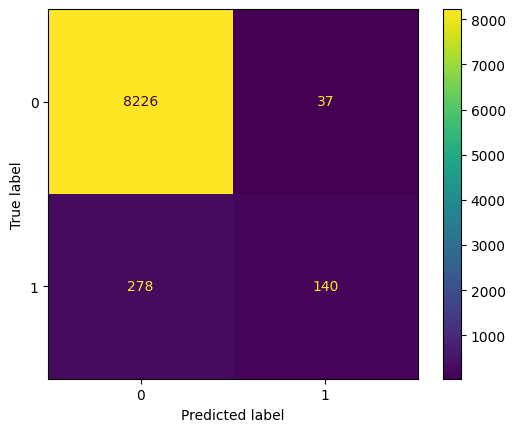

In [15]:
ConfusionMatrixDisplay.from_estimator(model_rf,X_test,y_test);

# Feauture Importance

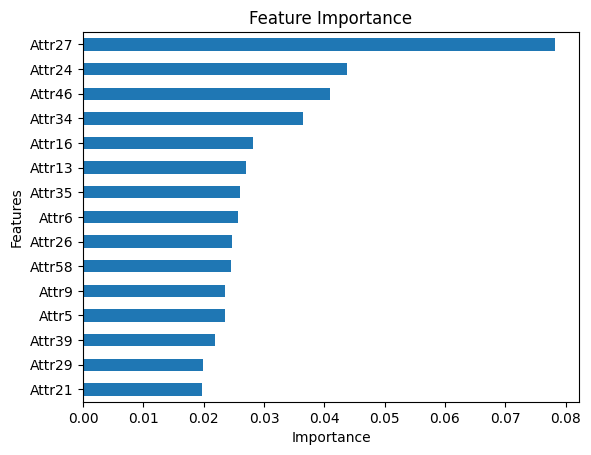

In [16]:
best_model = model_rf.best_estimator_

importances = best_model.named_steps["randomforestclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

# GRADIENT BOOSTING TREES
**Fitting multiple models in sequembnce using all the training data**


In [17]:
# A classifier that uses random forest
clf = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(classifier,X_train_over,y_train_over,cv=5,n_jobs=-1)

# Hyperparameter Tuning

In [18]:
params = {
    "simpleimputer__strategy": ["mean","median"],
    "gradientboostingclassifier__n_estimators": range(20,37,5),
    "gradientboostingclassifier__max_depth":range(2,5)    
}
params

{'simpleimputer__strategy': ['mean', 'median'],
 'gradientboostingclassifier__n_estimators': range(20, 37, 5),
 'gradientboostingclassifier__max_depth': range(2, 5)}

In [19]:
model_boost = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_boost.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gradientboostingclassifier__max_depth': range(2, 5), 'gradientboostingclassifier__n_estimators': range(20, 37, 5), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [20]:
results_boost = model_boost.cv_results_
cv_results_boost = pd.DataFrame(results_boost)
cv_results_boost.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,14.264779,0.809508,0.039911,0.001171,2,20,mean,"{'gradientboostingclassifier__max_depth': 2, '...",0.766432,0.774828,0.774357,0.774660,0.776626,0.773381,0.003564,24
1,14.391049,0.818698,0.051200,0.012136,2,20,median,"{'gradientboostingclassifier__max_depth': 2, '...",0.767794,0.777475,0.774357,0.783661,0.777761,0.776210,0.005173,23
2,17.557877,0.747958,0.050161,0.010358,2,25,mean,"{'gradientboostingclassifier__max_depth': 2, '...",0.775736,0.777853,0.776097,0.777610,0.786384,0.778736,0.003912,22
3,17.070857,0.452636,0.044620,0.005996,2,25,median,"{'gradientboostingclassifier__max_depth': 2, '...",0.785342,0.783526,0.784720,0.798714,0.786082,0.787677,0.005582,20
4,20.121991,0.872294,0.040823,0.001929,2,30,mean,"{'gradientboostingclassifier__max_depth': 2, '...",0.781257,0.782467,0.778517,0.779198,0.793116,0.782911,0.005295,21


In [21]:
best_params_boost = model_boost.best_params_
best_score_boost = model_boost.best_score_
best_model_boost = model_boost.best_estimator_


print("Best Model:", best_model_boost)
print("Best params:", best_params_boost)
print("Best Score:", best_score_boost)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=35,
                                            random_state=42))])
Best params: {'gradientboostingclassifier__max_depth': 4, 'gradientboostingclassifier__n_estimators': 35, 'simpleimputer__strategy': 'median'}
Best Score: 0.8738918897765109


# The Classification Report

In [30]:
report = classification_report(y_test, model_boost.predict(X_test))
print(report)

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      8263
           1       0.23      0.81      0.36       418

    accuracy                           0.86      8681
   macro avg       0.61      0.84      0.64      8681
weighted avg       0.95      0.86      0.89      8681



# Feauture Importance

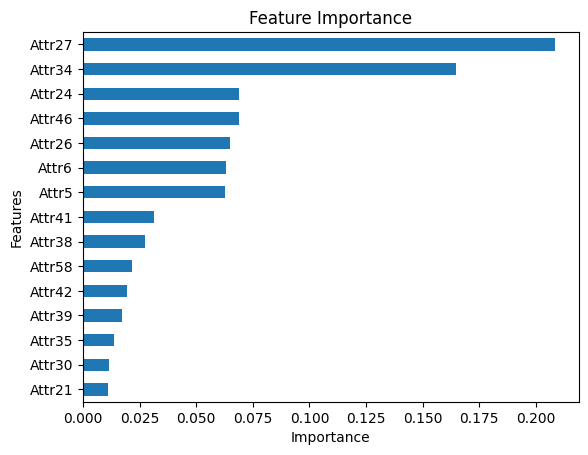

In [32]:
importances = best_model_boost.named_steps["gradientboostingclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

# Interactive Dashboard

In [49]:

def make_cnf_matrix(threshold):
    y_pred_proba = model_boost.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)

    conf_matrix = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    print(f"Profit: {tp*100_000_000}")
    print(f"Losses: {fp*250_000_000}")
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    print(f"Accuracy : {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall   : {recall:.2f}")

    print("Confusion Matrix:")
    print(conf_matrix)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)


thresh_widget = widgets.FloatSlider(min=0, max=1, value=0.5, step=0.05)
interact(make_cnf_matrix, threshold=thresh_widget);
    

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.05), Output()), _dom_cla…